In [3]:
import pandas as pd
adf=pd.read_csv("C:\\Users\\chandini ch\\Downloads\\kmeans_label_encoding_10000_rows(1).csv")
print(adf)

      customer_id  gender       city membership occupation  age  income  \
0               1    Male    Chennai     Silver   Business   34   93080   
1               2  Female    Chennai       Gold   Business   26   42289   
2               3    Male       Pune     Silver     Doctor   38   51346   
3               4    Male     Mumbai   Platinum    Student   47   45644   
4               5    Male    Chennai   Platinum   Engineer   28   48279   
...           ...     ...        ...        ...        ...  ...     ...   
9995         9996  Female       Pune   Platinum    Student   22   74617   
9996         9997    Male     Mumbai     Silver    Teacher   28  103292   
9997         9998  Female  Hyderabad     Silver    Teacher   33   22237   
9998         9999  Female  Bangalore     Silver   Business   51  121778   
9999        10000    Male      Delhi     Silver    Teacher   34   85263   

      spending_score  savings  
0                 93   459176  
1                 35   424892  
2  

In [3]:
adf.describe()

,customer_id,age,income,spending_score,savings
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,40.959900,109295.638900,50.559600,253232.28920
std,2886.89568,13.604617,51981.069107,28.999647,143016.42915
min,1.00000,18.000000,20005.000000,1.000000,5027.00000
25%,2500.75000,29.000000,64687.500000,25.000000,129492.00000
50%,5000.50000,41.000000,109156.500000,51.000000,253608.50000
75%,7500.25000,53.000000,153737.750000,76.000000,376919.50000
max,10000.00000,64.000000,199990.000000,100.000000,499898.00000


In [4]:
adf.shape

(10000, 9)

In [6]:
adf.info()
adf.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   customer_id     10000 non-null  int64
 1   gender          10000 non-null  str  
 2   city            10000 non-null  str  
 3   membership      10000 non-null  str  
 4   occupation      10000 non-null  str  
 5   age             10000 non-null  int64
 6   income          10000 non-null  int64
 7   spending_score  10000 non-null  int64
 8   savings         10000 non-null  int64
dtypes: int64(5), str(4)
memory usage: 703.3 KB


customer_id       0
gender            0
city              0
membership        0
occupation        0
age               0
income            0
spending_score    0
savings           0
dtype: int64

In [16]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
adf["le_gender"]=le.fit_transform(adf["gender"])

In [20]:
adf["le_city"]=le.fit_transform(adf["city"])
print(adf["le_city"])

0       1
1       1
2       5
3       4
4       1
       ..
9995    5
9996    4
9997    3
9998    0
9999    2
Name: le_city, Length: 10000, dtype: int64


In [19]:
adf["le_membership"]=le.fit_transform(adf["membership"])
print(adf["le_membership"])

0       2
1       0
2       2
3       1
4       1
       ..
9995    1
9996    2
9997    2
9998    2
9999    2
Name: le_membership, Length: 10000, dtype: int64


In [18]:
adf["le_occupation"]=le.fit_transform(adf["occupation"])
print(adf["le_occupation"])

0       0
1       0
2       1
3       3
4       2
       ..
9995    3
9996    4
9997    4
9998    0
9999    4
Name: le_occupation, Length: 10000, dtype: int64


In [23]:
le_df=adf[['customer_id','le_gender','le_city','le_membership','le_occupation','age','income','spending_score','savings']]
print(le_df)

      customer_id  le_gender  le_city  le_membership  le_occupation  age  \
0               1          1        1              2              0   34   
1               2          0        1              0              0   26   
2               3          1        5              2              1   38   
3               4          1        4              1              3   47   
4               5          1        1              1              2   28   
...           ...        ...      ...            ...            ...  ...   
9995         9996          0        5              1              3   22   
9996         9997          1        4              2              4   28   
9997         9998          0        3              2              4   33   
9998         9999          0        0              2              0   51   
9999        10000          1        2              2              4   34   

      income  spending_score  savings  
0      93080              93   459176  
1      

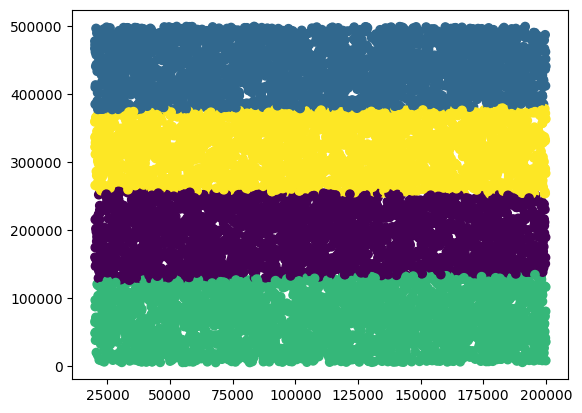

In [37]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
km=KMeans(n_clusters=4,random_state=50)
km.fit(le_df)
le_df['cluster']=km.labels_
plt.scatter(le_df["income"],le_df["savings"],c=km.labels_,cmap="viridis")
plt.show()


In [ ]:
# ---------------------------------------------------One Hot Encoding-----------------------------------------------

In [43]:
print(adf)

      customer_id  gender       city membership occupation  age  income  \
0               1    Male    Chennai     Silver   Business   34   93080   
1               2  Female    Chennai       Gold   Business   26   42289   
2               3    Male       Pune     Silver     Doctor   38   51346   
3               4    Male     Mumbai   Platinum    Student   47   45644   
4               5    Male    Chennai   Platinum   Engineer   28   48279   
...           ...     ...        ...        ...        ...  ...     ...   
9995         9996  Female       Pune   Platinum    Student   22   74617   
9996         9997    Male     Mumbai     Silver    Teacher   28  103292   
9997         9998  Female  Hyderabad     Silver    Teacher   33   22237   
9998         9999  Female  Bangalore     Silver   Business   51  121778   
9999        10000    Male      Delhi     Silver    Teacher   34   85263   

      spending_score  savings  occupation_Business  ...  occupation_Doctor  \
0                 93 

In [47]:
from sklearn.preprocessing import OneHotEncoder
ohe1=OneHotEncoder(sparse_output=False)
ohe1_gender=ohe1.fit_transform(adf[["gender"]])
ohe1_gender=pd.DataFrame(ohe1_gender,columns=ohe1.get_feature_names_out(["gender"]))
adf=pd.concat([adf,ohe1_gender],axis=1)

In [49]:
ohe1_city=ohe1.fit_transform(adf[["city"]])
ohe1_city=pd.DataFrame(ohe1_city,columns=ohe1.get_feature_names_out(["city"]))
adf=pd.concat([adf,ohe1_city],axis=1)

In [55]:
ohe1_membership=ohe1.fit_transform(adf[["membership"]])
ohe1_membership=pd.DataFrame(ohe1_membership,columns=ohe1.get_feature_names_out(["membership"]))
adf=pd.concat([adf,ohe1_membership],axis=1)


In [57]:
adf.drop_duplicates()

,customer_id,gender,city,membership,occupation,age,income,spending_score,savings,occupation_Business,...,membership_Silver,membership_Gold,membership_Platinum,membership_Silver,membership_Gold,membership_Platinum,membership_Silver,membership_Gold,membership_Platinum,membership_Silver
0,1,Male,Chennai,Silver,Business,34,93080,93,459176,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,Female,Chennai,Gold,Business,26,42289,35,424892,1.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,3,Male,Pune,Silver,Doctor,38,51346,76,130143,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
3,4,Male,Mumbai,Platinum,Student,47,45644,8,292433,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,5,Male,Chennai,Platinum,Engineer,28,48279,89,56237,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,Female,Pune,Platinum,Student,22,74617,69,61417,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
9996,9997,Male,Mumbai,Silver,Teacher,28,103292,52,280501,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
9997,9998,Female,Hyderabad,Silver,Teacher,33,22237,36,165787,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
9998,9999,Female,Bangalore,Silver,Business,51,121778,95,316249,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0


In [59]:
adf.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 97 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   customer_id          10000 non-null  int64  
 1   gender               10000 non-null  str    
 2   city                 10000 non-null  str    
 3   membership           10000 non-null  str    
 4   occupation           10000 non-null  str    
 5   age                  10000 non-null  int64  
 6   income               10000 non-null  int64  
 7   spending_score       10000 non-null  int64  
 8   savings              10000 non-null  int64  
 9   occupation_Business  10000 non-null  float64
 10  occupation_Doctor    10000 non-null  float64
 11  occupation_Engineer  10000 non-null  float64
 12  occupation_Student   10000 non-null  float64
 13  occupation_Teacher   10000 non-null  float64
 14  membership_Gold      10000 non-null  float64
 15  membership_Platinum  10000 non-null  float64
 16

In [61]:
ohe1_df=adf[["customer_id","gender_Female","gender_Male","city_Bangalore","city_Chennai","city_Delhi","city_Mumbai","city_Hyderabad","city_Pune","membership_Gold","membership_Platinum","membership_Silver","occupation_Business","occupation_Doctor","occupation_Engineer","occupation_Student","occupation_Teacher","age","income","spending_score","savings"]]
print(ohe1_df)

      customer_id  gender_Female  gender_Female  gender_Female  gender_Female  \
0               1            0.0            0.0            0.0            0.0   
1               2            1.0            1.0            1.0            1.0   
2               3            0.0            0.0            0.0            0.0   
3               4            0.0            0.0            0.0            0.0   
4               5            0.0            0.0            0.0            0.0   
...           ...            ...            ...            ...            ...   
9995         9996            1.0            1.0            1.0            1.0   
9996         9997            0.0            0.0            0.0            0.0   
9997         9998            1.0            1.0            1.0            1.0   
9998         9999            1.0            1.0            1.0            1.0   
9999        10000            0.0            0.0            0.0            0.0   

      gender_Female  gender

In [62]:
ohe1_df.duplicated().any()

np.False_

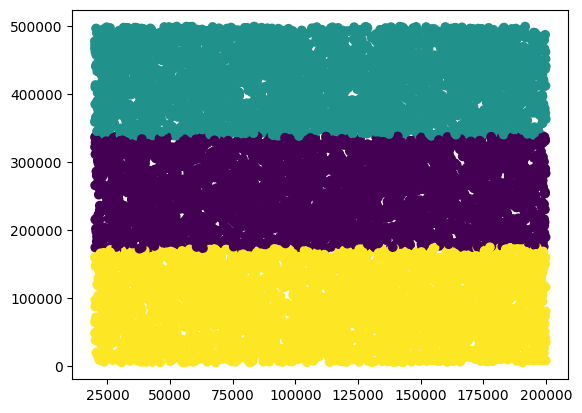

In [80]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
km1=KMeans(n_clusters=3,random_state=50)
km1.fit(ohe1_df)
ohe1_df['cluster']=km1.labels_
plt.scatter(ohe1_df["income"],ohe1_df["savings"],c=km1.labels_,cmap="viridis")
plt.show()

In [ ]:
#-----------------------------Optimizing the number of clusters using silhouette method------------------------------

In [68]:
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
x=ohe1_df
wcss=[]
silhouette_scores=[]
for i in range(2,11):
    km=KMeans(n_clusters=i,random_state=50)
    labels = km.fit_predict(x)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(x, labels))

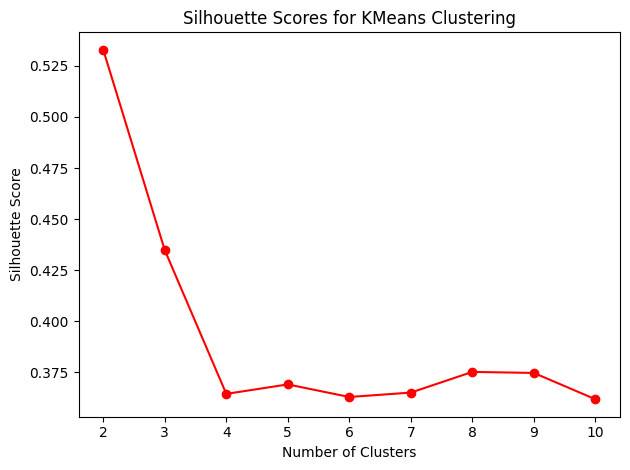

In [72]:
#plot silhouette scores
plt.plot(range(2,11), silhouette_scores, 'ro-')
plt.title('Silhouette Scores for KMeans Clustering')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

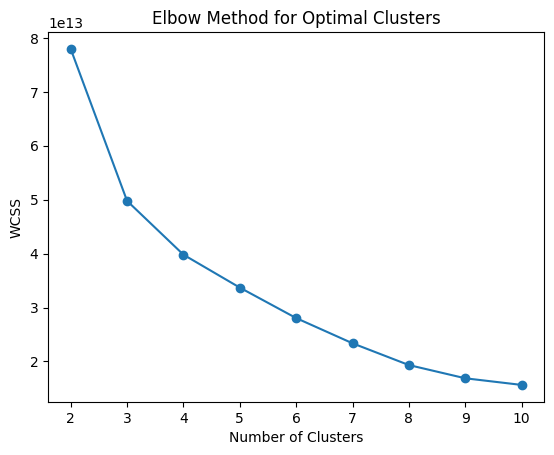

In [75]:
# Elbow method is nothing graph btwn number of clusters and wcss
plt.plot(range(2,11), wcss,'o-')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')    
plt.ylabel('WCSS')
plt.show()